# Experiment 4: Baseline XGBoost

Objective:

Evaluate whether a tree-based ensemble model can better capture the nonlinear relationships identified during exploratory data analysis and feature engineering.

No class balancing or hyperparameter tuning is applied in this experiment. This serves as the baseline XGBoost model for future comparisons.

XGBOOST BASELINE RESULTS
Accuracy : 0.9905
Precision: 0.9298
Recall   : 0.7794
F1 Score : 0.8480
ROC AUC  : 0.9764

Confusion Matrix
[[1928    4]
 [  15   53]]


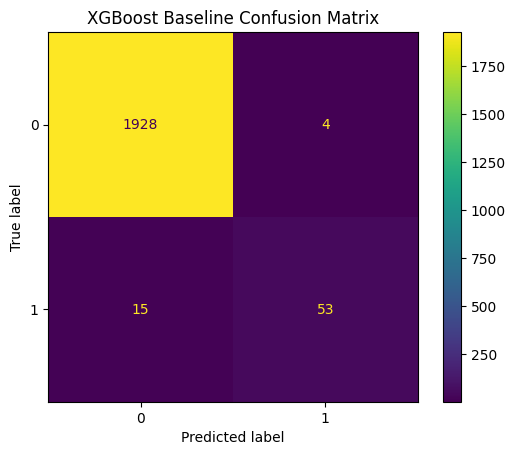

In [1]:
#imports
from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.data.load_data import load_ai4i_dataset
from src.features.feature_engineering import create_engineered_features
from src.features.preprocessing import prepare_modeling_dataset
from src.models.train_xgboost import build_xgboost_model

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# Data Pipeline
df = load_ai4i_dataset()

df = create_engineered_features(df)

df = prepare_modeling_dataset(df)

X = df.drop(columns=["Machine failure"])

y = df["Machine failure"]

X.columns.tolist()

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Model Training
model = build_xgboost_model()

model.fit(
    X_train,
    y_train
)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluation
print("=" * 50)
print("XGBOOST BASELINE RESULTS")
print("=" * 50)

print(
    f"Accuracy : {accuracy_score(y_test, y_pred):.4f}"
)

print(
    f"Precision: {precision_score(y_test, y_pred):.4f}"
)

print(
    f"Recall   : {recall_score(y_test, y_pred):.4f}"
)

print(
    f"F1 Score : {f1_score(y_test, y_pred):.4f}"
)

print(
    f"ROC AUC  : {roc_auc_score(y_test, y_prob):.4f}"
)

# Confusion Matrix
print("\nConfusion Matrix")
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("XGBoost Baseline Confusion Matrix")

plt.show()

## Experiment 4 Findings

The baseline XGBoost model substantially outperformed the logistic regression models across almost all evaluation metrics.

The model achieved an accuracy of 99.05%, precision of 92.98%, recall of 77.94%, F1-score of 84.80%, and ROC-AUC of 97.64%.

Compared to the balanced logistic regression model, XGBoost maintained very high precision while achieving competitive recall, reducing the number of false positives from 275 to only 4.

However, the model still missed 15 actual failures. Since predictive maintenance applications typically consider false negatives more expensive than false positives, improving recall remains an important objective.

The next experiment investigates whether adjusting the classification threshold can improve failure detection performance without modifying the underlying model.

## Experiment 5: XGBoost Threshold Tuning

In [2]:
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

y_prob = model.predict_proba(X_test)[:, 1]

thresholds = [0.50, 0.40, 0.30, 0.20]

results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_test,
        y_pred_threshold
    )

    tn, fp, fn, tp = cm.ravel()

    results.append({

        "Threshold": threshold,

        "Accuracy":
        accuracy_score(
            y_test,
            y_pred_threshold
        ),

        "Precision":
        precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),

        "Recall":
        recall_score(
            y_test,
            y_pred_threshold
        ),

        "F1":
        f1_score(
            y_test,
            y_pred_threshold
        ),

        "False Positives":
        fp,

        "False Negatives":
        fn,

        "True Positives":
        tp,

        "True Negatives":
        tn

    })

results_df = pd.DataFrame(results)

print("=" * 70)
print("XGBOOST THRESHOLD TUNING")
print("=" * 70)

results_df

XGBOOST THRESHOLD TUNING


,Threshold,Accuracy,Precision,Recall,F1,False Positives,False Negatives,True Positives,True Negatives
0,0.5,0.9905,0.929825,0.779412,0.848000,4,15,53,1928
1,0.4,0.9910,0.903226,0.823529,0.861538,6,12,56,1926
2,0.3,0.9895,0.850746,0.838235,0.844444,10,11,57,1922
3,0.2,0.9865,0.780822,0.838235,0.808511,16,11,57,1916


## Experiment 5 Findings

Threshold tuning demonstrated that the baseline XGBoost model already produces well separated probability estimates.

Reducing the threshold from 0.50 to 0.40 improved recall from 77.94% to 82.35% while only increasing false positives from 4 to 6.

A threshold of 0.40 also achieved the highest F1-score among the evaluated thresholds, providing the best balance between failure detection and false alarms.

Further reducing the threshold increased false positives without providing meaningful improvements in recall, making lower thresholds less suitable for this predictive maintenance application.

Based on these experiments, a decision threshold of 0.40 is selected for subsequent model comparisons.

## Experiment 6: Balanced XGBoost

The baseline XGBoost model achieved strong overall performance but continued to miss a number of machine failures.

To address the severe class imbalance, this experiment applies XGBoost's `scale_pos_weight` parameter.

The positive class weight is calculated as the ratio between healthy and failed machines, encouraging the model to place greater emphasis on correctly identifying failures.

This approach preserves the original dataset while making the learning algorithm more sensitive to the minority class.

BALANCED XGBOOST RESULTS
Accuracy : 0.9715
Precision: 0.5495
Recall   : 0.8971
F1 Score : 0.6816
ROC AUC  : 0.9813

Confusion Matrix
[[1882   50]
 [   7   61]]


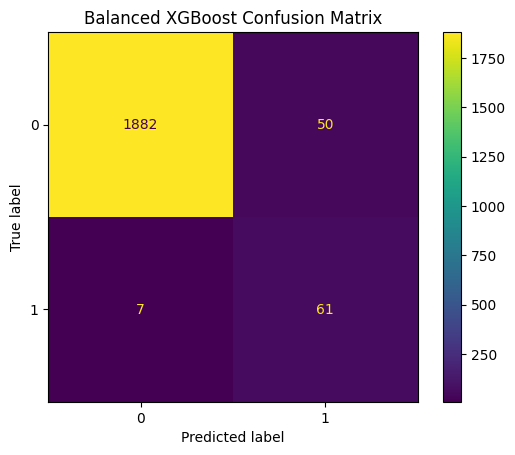

In [1]:
# Balanced XGBoost Experiment
from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.data.load_data import load_ai4i_dataset
from src.features.feature_engineering import create_engineered_features
from src.features.preprocessing import prepare_modeling_dataset
from src.models.train_xgboost import (
    build_balanced_xgboost_model
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# Data Pipeline
df = load_ai4i_dataset()

df = create_engineered_features(df)

df = prepare_modeling_dataset(df)

X = df.drop(
    columns=["Machine failure"]
)

y = df["Machine failure"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

# Model Training
model = build_balanced_xgboost_model()

model.fit(
    X_train,
    y_train
)

# Predictions
y_pred = model.predict(
    X_test
)

y_prob = model.predict_proba(
    X_test
)[:, 1]

# Evaluation
print("=" * 60)
print("BALANCED XGBOOST RESULTS")
print("=" * 60)

print(
    f"Accuracy : {accuracy_score(y_test, y_pred):.4f}"
)

print(
    f"Precision: {precision_score(y_test, y_pred):.4f}"
)

print(
    f"Recall   : {recall_score(y_test, y_pred):.4f}"
)

print(
    f"F1 Score : {f1_score(y_test, y_pred):.4f}"
)

print(
    f"ROC AUC  : {roc_auc_score(y_test, y_prob):.4f}"
)
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix")
print(cm)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title(
    "Balanced XGBoost Confusion Matrix"
)

plt.show()

## Experiment 6 Findings

Applying class weighting through the `scale_pos_weight` parameter substantially increased recall from 77.94% to 89.71%, reducing missed failures from 15 to 7.

However, this improvement came at the cost of a significant increase in false positives, which increased from 4 to 50.

Although the balanced model achieved a slightly higher ROC-AUC score, its overall F1-score decreased compared to the threshold-tuned baseline XGBoost model.

Based on these experiments, the threshold-tuned baseline XGBoost model (threshold = 0.40) remains the preferred solution because it provides a stronger balance between failure detection and false alarm rate.


## Experiment 7: Hyperparameter Tuning

The baseline XGBoost model demonstrated strong predictive performance.

This experiment investigates whether controlled adjustments to key model parameters can further improve the balance between precision and recall.

Rather than performing an exhaustive grid search, a guided hyperparameter tuning strategy is adopted to better understand the effect of individual parameters on model behavior.


In [1]:
# Imports
from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import pandas as pd

from src.data.load_data import load_ai4i_dataset

from src.features.feature_engineering import (
    create_engineered_features
)

from src.features.preprocessing import (
    prepare_modeling_dataset
)

from src.models.train_xgboost import (
    build_tuned_xgboost_model
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Data Pipeline
df = load_ai4i_dataset()

df = create_engineered_features(df)

df = prepare_modeling_dataset(df)

X = df.drop(
    columns=["Machine failure"]
)

y = df["Machine failure"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

# Hyperparameter Tuning
depths = [3, 4, 5, 6]

results = []

for depth in depths:

    model = build_tuned_xgboost_model(

        max_depth=depth

    )

    model.fit(

        X_train,

        y_train

    )

    y_prob = model.predict_proba(

        X_test

    )[:, 1]

    # Current best threshold

    y_pred = (

        y_prob >= 0.40

    ).astype(int)

    results.append({

        "Max Depth": depth,

        "Precision":
        precision_score(
            y_test,
            y_pred
        ),

        "Recall":
        recall_score(
            y_test,
            y_pred
        ),

        "F1":
        f1_score(
            y_test,
            y_pred
        ),

        "ROC AUC":
        roc_auc_score(
            y_test,
            y_prob
        )

    })


results_df = pd.DataFrame(
    results
)

print("=" * 70)
print("MAX DEPTH TUNING")
print("=" * 70)

results_df

MAX DEPTH TUNING


,Max Depth,Precision,Recall,F1,ROC AUC
0,3,0.900000,0.794118,0.843750,0.979566
1,4,0.903226,0.823529,0.861538,0.976404
2,5,0.868852,0.779412,0.821705,0.973092
3,6,0.873016,0.808824,0.839695,0.976069


## Experiment 7 Findings

The maximum tree depth parameter was evaluated to understand its impact on model complexity and predictive performance.

A depth of 4 achieved the best balance across precision, recall, and F1-score, producing the strongest overall classification performance.

Increasing the tree depth beyond 4 did not improve the model and instead led to slight reductions in both F1-score and ROC-AUC, indicating the onset of overfitting.

Based on these results, a maximum depth of 4 is retained for subsequent experiments.


## Experiment 8: Number of Trees

This experiment evaluates the impact of the number of boosting trees while keeping all other parameters fixed.

The objective is to determine whether additional trees improve the balance between precision and recall without introducing overfitting.

In [2]:
# ===================================================
# Imports
# ===================================================

from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import pandas as pd

from src.data.load_data import load_ai4i_dataset

from src.features.feature_engineering import (
    create_engineered_features
)

from src.features.preprocessing import (
    prepare_modeling_dataset
)

from src.models.train_xgboost import (
    build_tuned_xgboost_model
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


# ===================================================
# Data Pipeline
# ===================================================

df = load_ai4i_dataset()

df = create_engineered_features(df)

df = prepare_modeling_dataset(df)

X = df.drop(
    columns=["Machine failure"]
)

y = df["Machine failure"]


# ===================================================
# Train Test Split
# ===================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)


# ===================================================
# n_estimators Tuning
# ===================================================

estimators = [100, 150, 200, 300]

results = []

for n in estimators:

    model = build_tuned_xgboost_model(

        max_depth=4,

        n_estimators=n,

        learning_rate=0.1

    )

    model.fit(

        X_train,

        y_train

    )

    y_prob = model.predict_proba(

        X_test

    )[:, 1]

    # Current best threshold

    y_pred = (

        y_prob >= 0.40

    ).astype(int)

    results.append({

        "n_estimators": n,

        "Precision":
        precision_score(
            y_test,
            y_pred
        ),

        "Recall":
        recall_score(
            y_test,
            y_pred
        ),

        "F1":
        f1_score(
            y_test,
            y_pred
        ),

        "ROC AUC":
        roc_auc_score(
            y_test,
            y_prob
        )

    })

results_df = pd.DataFrame(
    results
)

print("=" * 70)
print("N_ESTIMATORS TUNING")
print("=" * 70)

results_df

N_ESTIMATORS TUNING


,n_estimators,Precision,Recall,F1,ROC AUC
0,100,0.903226,0.823529,0.861538,0.976404
1,150,0.901639,0.808824,0.852713,0.974052
2,200,0.887097,0.808824,0.846154,0.974539
3,300,0.887097,0.808824,0.846154,0.970908


## Experiment 8 Findings

Increasing the number of trees beyond 100 did not improve model performance.

The baseline configuration with 100 estimators achieved the best balance between precision, recall, and F1-score, so it is retained for subsequent experiments.


## Experiment 9: Learning Rate

This experiment evaluates the impact of the learning rate while keeping all other hyperparameters fixed.

The objective is to determine the best balance between learning speed and model generalization.


In [3]:
# ===================================================
# Imports
# ===================================================

from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import pandas as pd

from src.data.load_data import load_ai4i_dataset

from src.features.feature_engineering import (
    create_engineered_features
)

from src.features.preprocessing import (
    prepare_modeling_dataset
)

from src.models.train_xgboost import (
    build_tuned_xgboost_model
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


# ===================================================
# Data Pipeline
# ===================================================

df = load_ai4i_dataset()

df = create_engineered_features(df)

df = prepare_modeling_dataset(df)

X = df.drop(
    columns=["Machine failure"]
)

y = df["Machine failure"]

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)


# ===================================================
# Learning Rate Tuning
# ===================================================

learning_rates = [0.05, 0.10, 0.20, 0.30]

results = []

for lr in learning_rates:

    model = build_tuned_xgboost_model(

        max_depth=4,

        n_estimators=100,

        learning_rate=lr

    )

    model.fit(

        X_train,

        y_train

    )

    y_prob = model.predict_proba(

        X_test

    )[:, 1]

    y_pred = (

        y_prob >= 0.40

    ).astype(int)

    results.append({

        "Learning Rate": lr,

        "Precision":
        precision_score(
            y_test,
            y_pred
        ),

        "Recall":
        recall_score(
            y_test,
            y_pred
        ),

        "F1":
        f1_score(
            y_test,
            y_pred
        ),

        "ROC AUC":
        roc_auc_score(
            y_test,
            y_prob
        )

    })

results_df = pd.DataFrame(
    results
)

print("=" * 70)
print("LEARNING RATE TUNING")
print("=" * 70)

results_df

LEARNING RATE TUNING


,Learning Rate,Precision,Recall,F1,ROC AUC
0,0.05,0.901639,0.808824,0.852713,0.973789
1,0.10,0.903226,0.823529,0.861538,0.976404
2,0.20,0.868852,0.779412,0.821705,0.968472
3,0.30,0.857143,0.794118,0.824427,0.979212


## Experiment 9 Findings

A learning rate of 0.10 provided the best overall balance between precision, recall, and F1-score.

Both lower and higher learning rates resulted in slight performance degradation, so the baseline value of 0.10 is retained.


## Experiment 10: Minimum Child Weight

This experiment evaluates the effect of the minimum child weight parameter while keeping all other hyperparameters fixed.

The objective is to control model complexity and reduce potential overfitting.


In [4]:
# ===================================================
# Imports
# ===================================================

from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import pandas as pd

from src.data.load_data import load_ai4i_dataset

from src.features.feature_engineering import (
    create_engineered_features
)

from src.features.preprocessing import (
    prepare_modeling_dataset
)

from src.models.train_xgboost import (
    build_tuned_xgboost_model
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score


)


# ===================================================
# Data Pipeline
# ===================================================

df = load_ai4i_dataset()

df = create_engineered_features(df)

df = prepare_modeling_dataset(df)

X = df.drop(
    columns=["Machine failure"]
)

y = df["Machine failure"]

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)


# ===================================================
# min_child_weight Tuning
# ===================================================

weights = [1, 3, 5, 7]

results = []

for weight in weights:

    model = build_tuned_xgboost_model(

        max_depth=4,

        n_estimators=100,

        learning_rate=0.10,

        min_child_weight=weight

    )

    model.fit(

        X_train,

        y_train

    )

    y_prob = model.predict_proba(

        X_test

    )[:, 1]

    y_pred = (

        y_prob >= 0.40

    ).astype(int)

    results.append({

        "Min Child Weight": weight,

        "Precision":
        precision_score(
            y_test,
            y_pred
        ),

        "Recall":
        recall_score(
            y_test,
            y_pred
        ),

        "F1":
        f1_score(
            y_test,
            y_pred
        ),

        "ROC AUC":
        roc_auc_score(
            y_test,
            y_prob
        )

    })

results_df = pd.DataFrame(
    results
)

print("=" * 70)
print("MIN_CHILD_WEIGHT TUNING")
print("=" * 70)

results_df

MIN_CHILD_WEIGHT TUNING


,Min Child Weight,Precision,Recall,F1,ROC AUC
0,1,0.903226,0.823529,0.861538,0.976404
1,3,0.876923,0.838235,0.857143,0.972590
2,5,0.859375,0.808824,0.833333,0.980453
3,7,0.846154,0.808824,0.827068,0.976411
